<a href="https://colab.research.google.com/github/Benard-bb/MOBILE/blob/main/world_happinness_report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This analysis explores the 2019 World Happiness Report, a dataset covering 153 countries across multiple global regions. Each country is scored on factors including economic output, social support, health, freedom, generosity, and perceptions of corruption. This notebook aims to answer three questions:

1. Which factors most strongly predict a country's happiness score?
2. How do happiness scores vary across regions?
3. Are there notable outliers, and what might explain them?







In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

url = "https://raw.githubusercontent.com/PhilippeCodes/World-Happiness-Report-Data-Analysis/master/World%20Happiness%20Report.csv"
whp_data = pd.read_csv(url)
whp_data.head()

,Country,Happiness Rank,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption,Dystopia,Job Satisfaction,Region
0,Norway,1,7.537,1.616463,1.533524,0.796667,0.635423,0.362012,0.315964,2.277027,94.6,Western Europe
1,Denmark,2,7.522,1.482383,1.551122,0.792566,0.626007,0.355280,0.400770,2.313707,93.5,Western Europe
2,Iceland,3,7.504,1.480633,1.610574,0.833552,0.627163,0.475540,0.153527,2.322715,94.5,Western Europe
3,Switzerland,4,7.494,1.564980,1.516912,0.858131,0.620071,0.290549,0.367007,2.276716,93.7,Western Europe
4,Finland,5,7.469,1.443572,1.540247,0.809158,0.617951,0.245483,0.382612,2.430182,91.2,Western Europe


In [ ]:

whp_data.shape

(153, 12)

In [ ]:
whp_data.describe()

,Happiness Rank,Happiness Score,Economy,Family,Health,Freedom,Generosity,Corruption,Dystopia,Job Satisfaction
count,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,153.000000,151.000000
mean,78.169935,5.349281,0.982433,1.186630,0.550117,0.408489,0.245324,0.123179,1.853072,75.209934
std,45.008741,1.134997,0.421901,0.288441,0.237769,0.150744,0.134395,0.102133,0.499490,12.962365
min,1.000000,2.693000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.377914,44.400000
25%,40.000000,4.497000,0.659517,1.041990,0.364509,0.300741,0.153075,0.057070,1.597970,68.950000
50%,78.000000,5.279000,1.064578,1.251826,0.606042,0.437454,0.231503,0.089848,1.832910,78.100000
75%,117.000000,6.098000,1.315175,1.416404,0.719217,0.518631,0.322228,0.153066,2.150801,85.100000
max,155.000000,7.537000,1.870766,1.610574,0.949492,0.658249,0.838075,0.464308,3.117485,95.100000


The codes above tells us or dataset has 153 rows with 12 columns.
columns representing catagories that affect the hapinnes of the person.


In [ ]:
whp_data.isnull().sum()

,0
Country,0
Happiness Rank,0
Happiness Score,0
Economy,0
Family,0
Health,0
Freedom,0
Generosity,0
Corruption,0
Dystopia,0


from the cell above, we realize the job satisfaction colomn has 2 missing values. i am going to go on ahead and fill these spaces with the averages to ensre we get precise reslts


In [ ]:
whp_data['Job Satisfaction'] = whp_data['Job Satisfaction'].fillna(whp_data['Job Satisfaction'].mean())

In [ ]:
whp_data['Job Satisfaction'].isnull().sum()

np.int64(0)

so I now go on ahead to create charts for the datasets to show the hidden relations

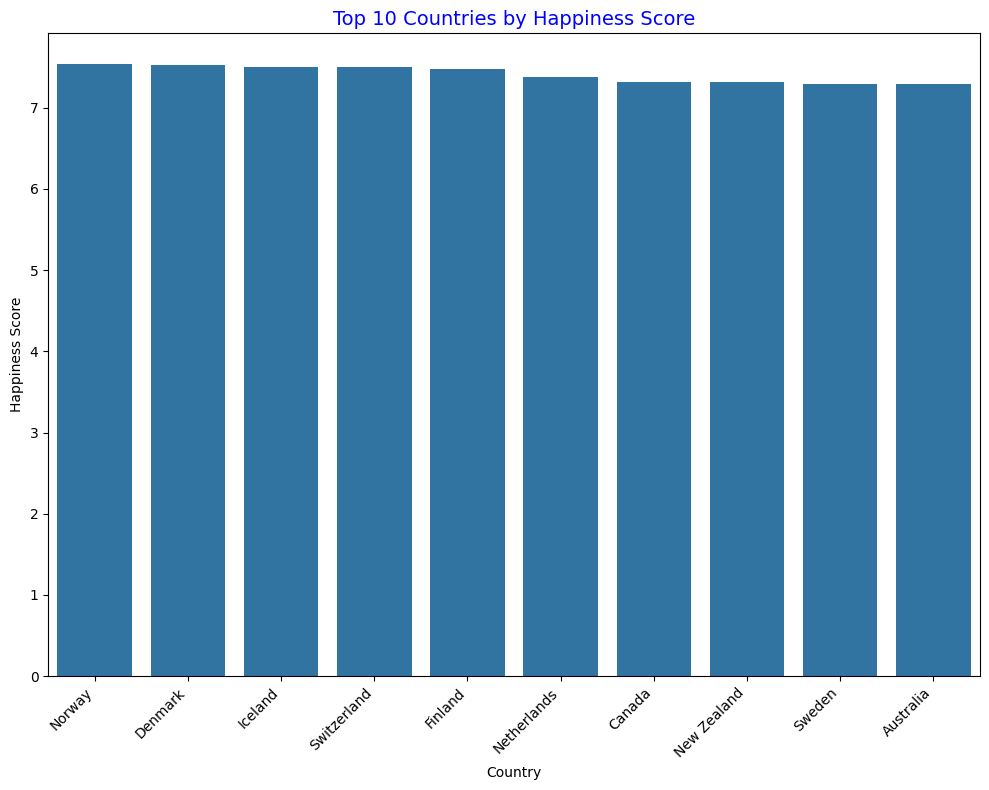

In [ ]:
plt.figure(figsize=(10, 8))

top_10_countries = whp_data.sort_values(by='Happiness Score', ascending=False).head(10)
sns.barplot(x = 'Country', y = 'Happiness Score', data = top_10_countries)
plt.title('Top 10 Countries by Happiness Score',
          color = 'Blue',
          fontsize = 14)
plt.xlabel('Country')
plt.ylabel('Happiness Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


<Axes: >

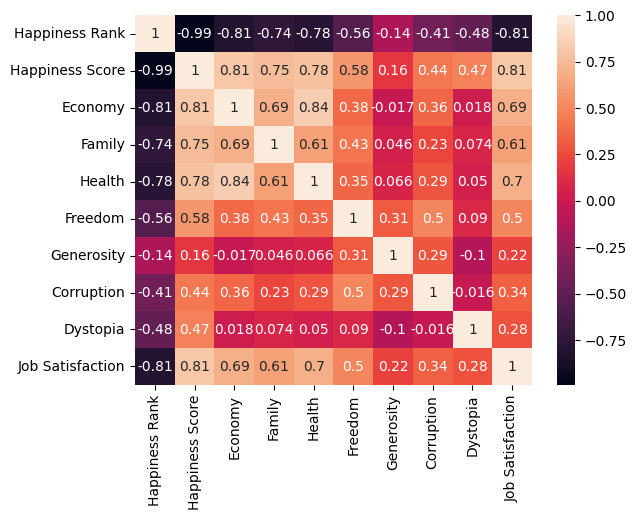

In [ ]:

sns.heatmap(whp_data.corr(numeric_only=True), annot=True)

From the heatmap above, it shows the correlation or how the various factors affect eachother. With values closer to zero denoting a very little or no correlation, values closer to one a very strong positive correlation and a vale closer to negatie 1 a very strong negative correlation.

<Axes: xlabel='Economy', ylabel='Happiness Score'>

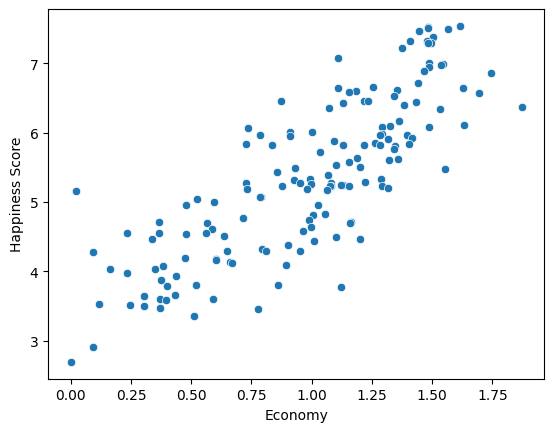

In [ ]:
sns.scatterplot(x = whp_data['Economy'], y = whp_data['Happiness Score'])

<Axes: xlabel='Job Satisfaction', ylabel='Happiness Score'>

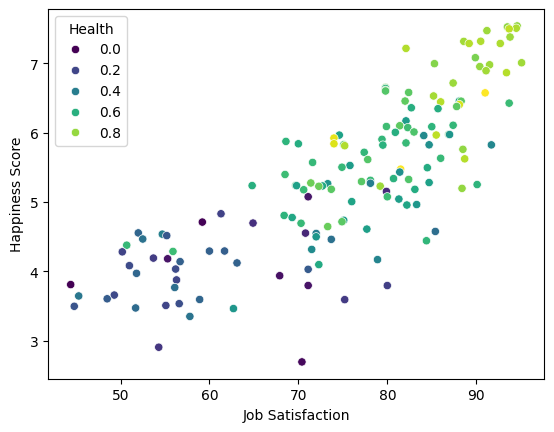

In [ ]:
sns.scatterplot(x ='Job Satisfaction', y = 'Happiness Score', hue = 'Health', data=whp_data, palette='viridis')

from the charts above it can be inffered that, good health and job satisfaction makes an individal happy.

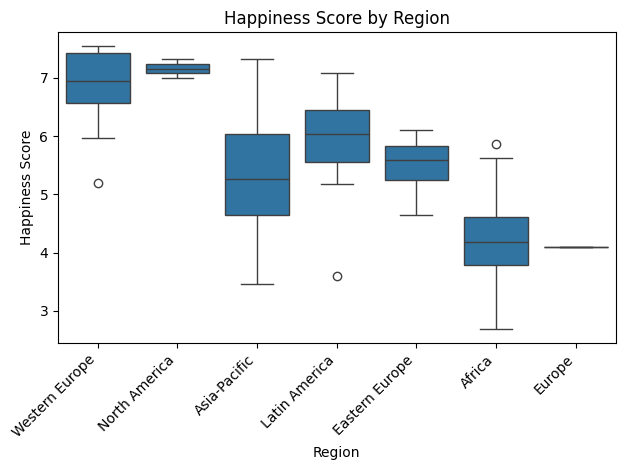

In [ ]:

sns.boxplot(x = 'Region', y = 'Happiness Score', data = whp_data)
plt.xticks(rotation=45, ha='right')
plt.title('Happiness Score by Region')
plt.xlabel('Region')
plt.ylabel('Happiness Score')
plt.tight_layout()

In [ ]:
whp_data.groupby('Region')['Happiness Score'].mean().sort_values()

,Happiness Score
Region,
Europe,4.096000
Africa,4.239500
Asia-Pacific,5.358326
Eastern Europe,5.513091
Latin America,5.957818
Western Europe,6.880474
North America,7.154500


The boxplot above compares happiness score distributions across regions. Western Europe and North America rank highest, with median scores around 7.0, and both show relatively tight distributions — meaning most countries in these regions score similarly. North America in particular has the narrowest spread, which makes sense given it only contains a few high-income countries.
Asia-Pacific shows the widest spread of any region, with scores ranging from roughly 3.5 to 7.3. This reflects how economically and socially diverse the region is — wealthy countries like Australia and New Zealand sit alongside much poorer nations.
Latin America sits in the middle range with a median around 6.0, though it has a notable outlier below 3.6, which likely represents a country experiencing significant instability or economic hardship.
Africa has the lowest median score and a wide spread, indicating high inequality in wellbeing across the continent. One outlier sits near 5.9 — considerably above Africa's typical range — suggesting at least one country significantly outperforms its regional peers.
The "Europe" category appears to contain only a single country (shown as a flat line with no box), which suggests a data labelling issue — it is likely a country that should have been grouped under Western or Eastern Europe

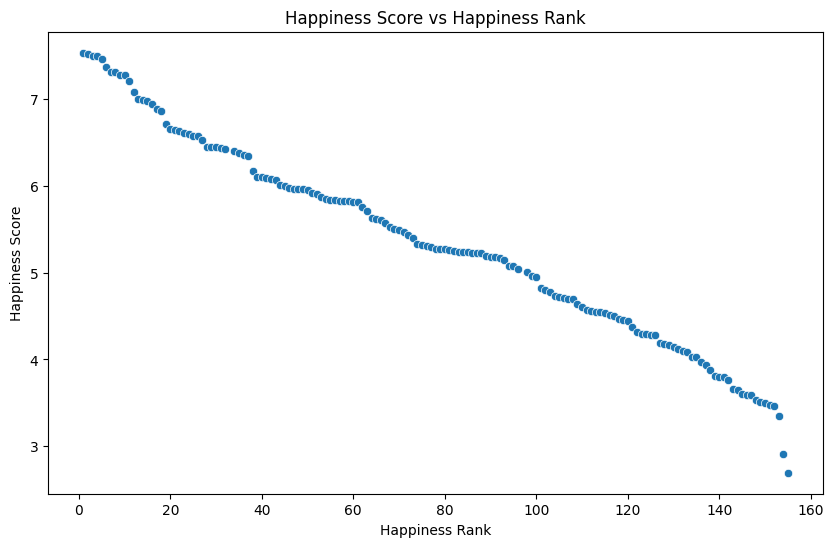

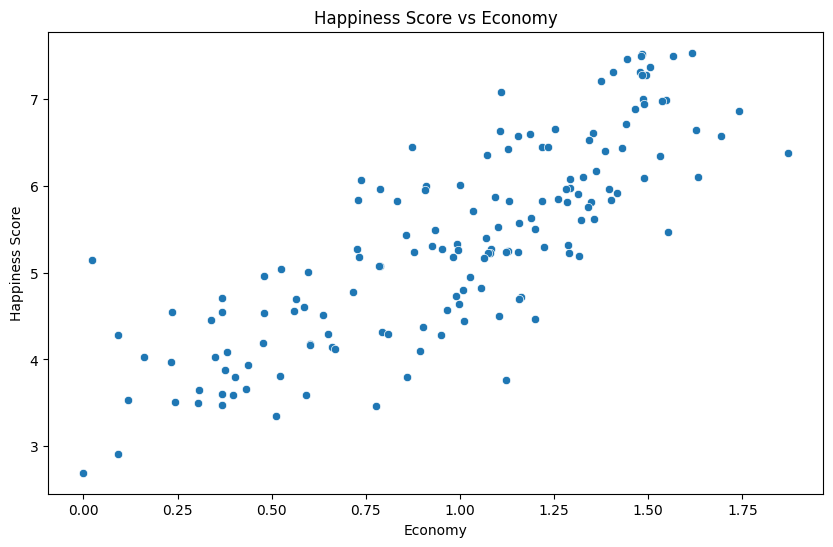

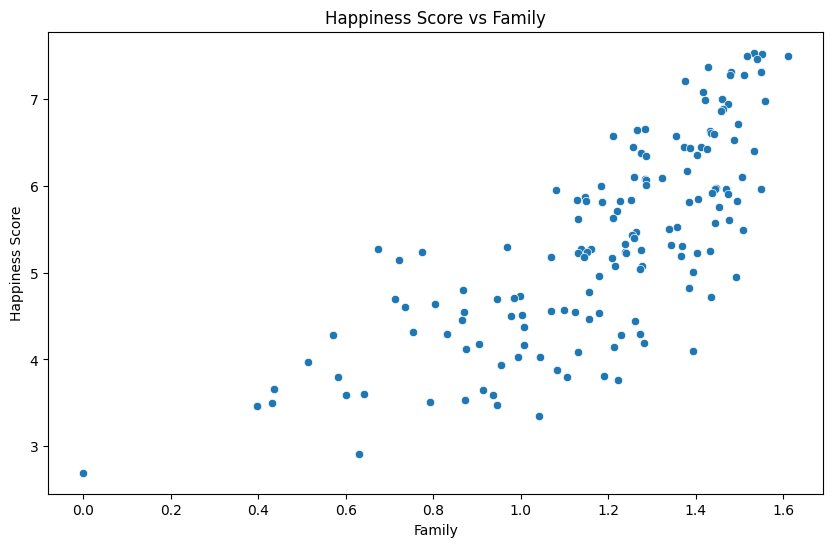

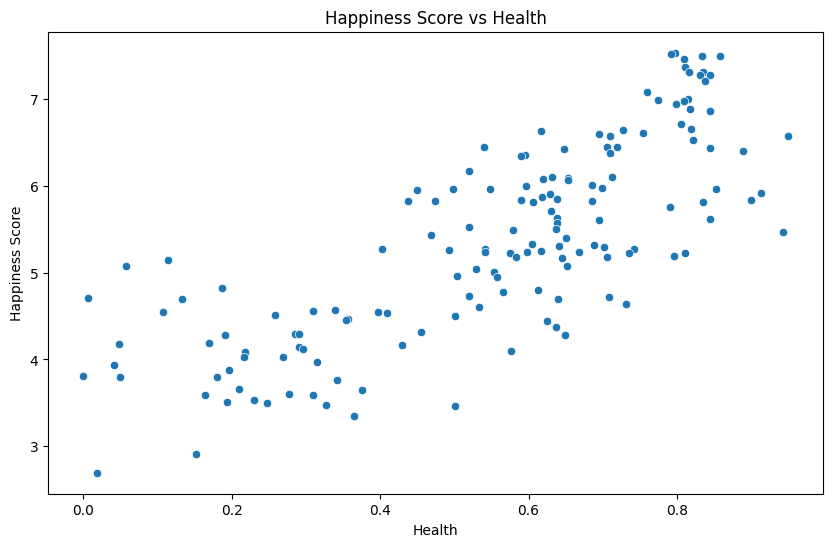

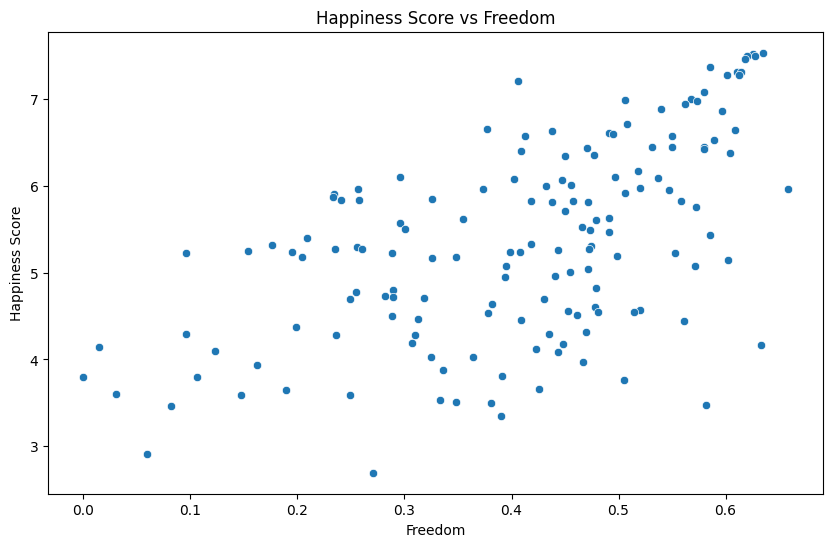

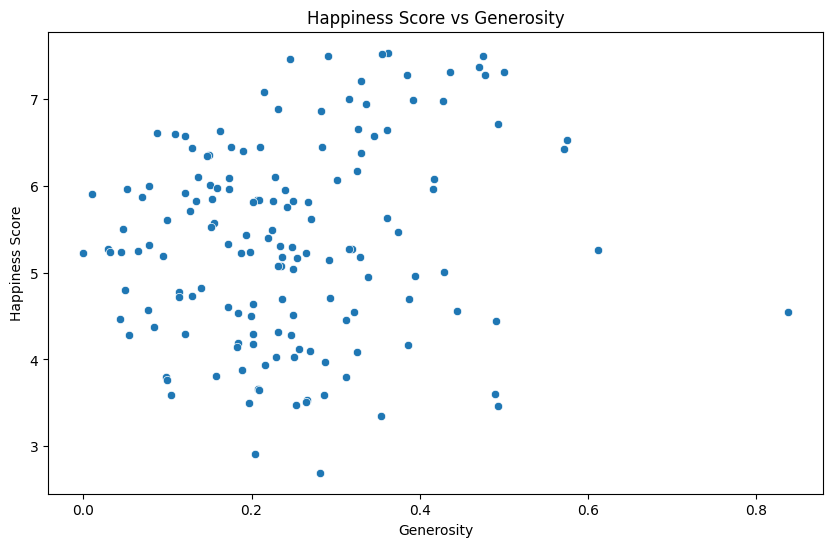

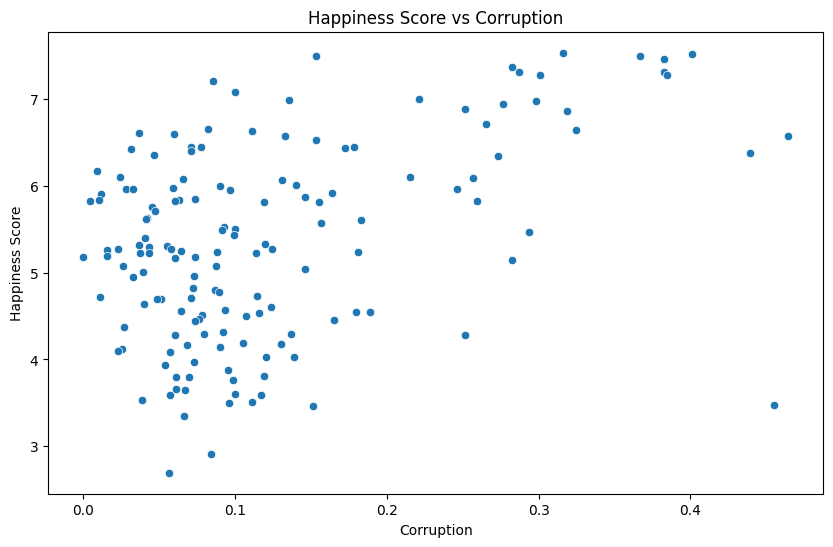

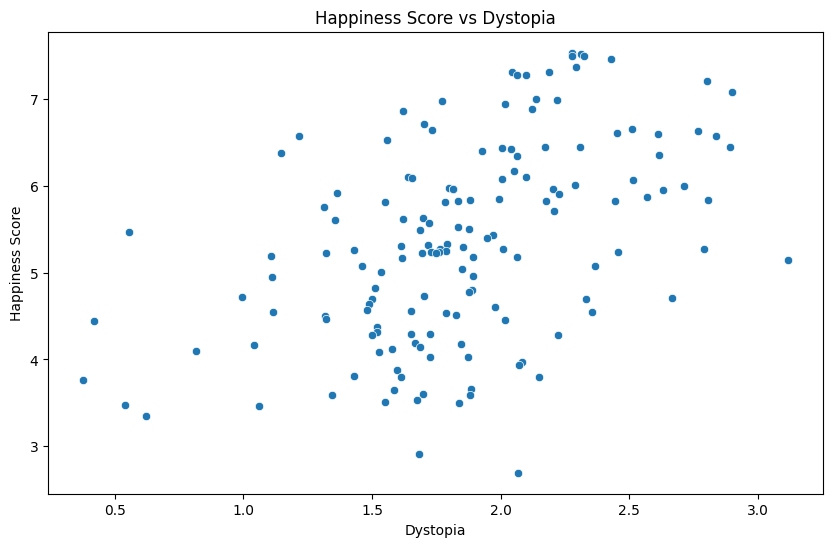

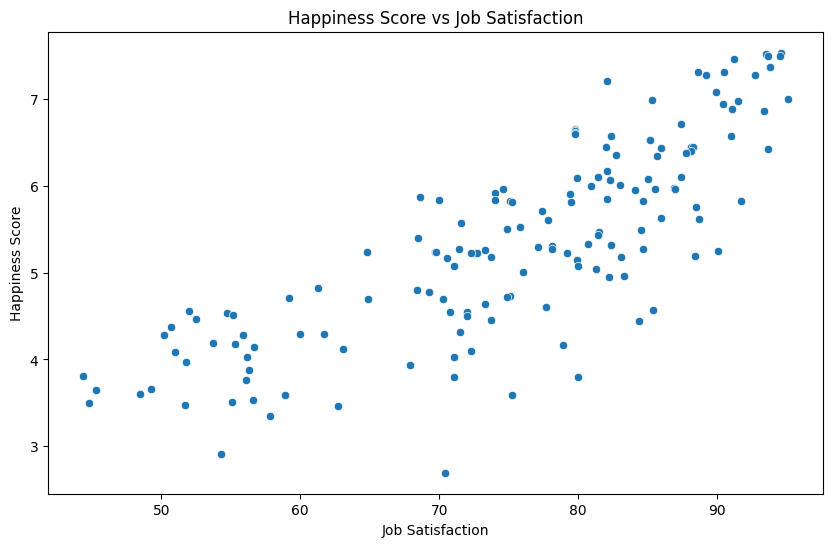

In [ ]:
numerical_cols = whp_data.select_dtypes(include='number').columns.tolist()
numerical_cols.remove('Happiness Score')

for col in numerical_cols:
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=col, y='Happiness Score', data=whp_data)
    plt.title(f'Happiness Score vs {col}')

This analysis set out to answer three questions about the 2019 World Happiness Report.
On the first question, the data clearly shows that economy, health, family, and job satisfaction are the strongest predictors of a country's happiness score. Factors like generosity and perceptions of corruption showed weaker and less consistent relationships.
On the second question, regional differences are significant. Western Europe and North America consistently score highest, while Africa scores lowest with the widest variation between countries. Asia-Pacific showed the most internal diversity, reflecting the region's economic and social range.
On the third question, several outliers were identified. Latin America contained one country scoring well below its regional peers, likely reflecting political or economic instability. Within Africa, one country scored notably higher than the rest of the continent. The dataset also contains a single entry labelled only "Europe" which appears to be a classification error.
Overall, the findings suggest that material wellbeing, economic stability, physical health and social support, forms the foundation of national happiness, while factors like generosity and corruption play a secondary role. Addressing these core needs would likely have the greatest impact on improving happiness scores, particularly in lower-ranked regions.